### 3MT using Florence-2 + Mamba-YOLO + Motion-Mamba
> 1 - Images   
> 2 - Videos   
> 3 - Texts  

In [16]:
!nvidia-smi

Fri Dec 20 13:20:02 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:01:00.0  On |                  N/A |
| 30%   31C    P8             36W /  350W |    2704MiB /  24576MiB |     25%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
!pip install transformers

In [18]:
!pip install einops timm

In [19]:
from transformers import AutoProcessor, AutoModelForCausalLM  
from PIL import Image
import requests
import copy
import torch
%matplotlib inline  

In [ ]:
model_id = 'microsoft/Florence-2-large'
model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True, torch_dtype='auto').eval().cuda()
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

## Define the Prediction Function

In [15]:
def m3f_florence(task_prompt, text_input=None):
    if text_input is None:
        prompt = task_prompt
    else:
        prompt = task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt").to('cuda', torch.float16)
    generated_ids = model.generate(
      input_ids=inputs["input_ids"].cuda(),
      pixel_values=inputs["pixel_values"].cuda(),
      max_new_tokens=1024,
      early_stopping=False,
      do_sample=False,
      num_beams=3,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(
        generated_text, 
        task=task_prompt, 
        image_size=(image.width, image.height)
    )

    return parsed_answer

#### 3MT Prediction Function

In [10]:
# import cv2
# import torch

# def m3f_florence(task_prompt, text_input=None, image=None, video_path=None, output_file="frame_details.txt"):
#     if text_input is None:
#         prompt = task_prompt
#     else:
#         prompt = task_prompt + text_input

#     with open(output_file, 'w') as file:
#         if video_path:

#             video = cv2.VideoCapture(video_path)
#             frame_count = 0
#             while video.isOpened():
#                 ret, frame = cap.read()
#                 if not ret:
#                     break  

#                 image_tensor = processor(images=frame, return_tensors="pt").to('cuda', torch.float16)
#                 inputs = processor(text=prompt, images=image_tensor["pixel_values"], return_tensors="pt").to('cuda', torch.float16)

#                 generated_ids = model.generate(
#                     input_ids=inputs["input_ids"].cuda(),
#                     pixel_values=inputs["pixel_values"].cuda(),
#                     max_new_tokens=1024,
#                     early_stopping=False,
#                     do_sample=False,
#                     num_beams=3,
#                 )
#                 # Decode and process the generated text
#                 generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
#                 parsed_answer = processor.post_process_generation(
#                     generated_text, 
#                     task=task_prompt, 
#                     image_size=(frame.shape[1], frame.shape[0])
#                 )

#                 file.write(f"Frame {frame_count}:\n{parsed_answer}\n\n")
#                 frame_count += 1

#             cap.release()

#         elif image is not None:
#             inputs = processor(text=prompt, images=image, return_tensors="pt").to('cuda', torch.float16)
#             generated_ids = model.generate(
#                 input_ids=inputs["input_ids"].cuda(),
#                 pixel_values=inputs["pixel_values"].cuda(),
#                 max_new_tokens=1024,
#                 early_stopping=False,
#                 do_sample=False,
#                 num_beams=3,
#             )
#             generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
#             parsed_answer = processor.post_process_generation(
#                 generated_text, 
#                 task=task_prompt, 
#                 image_size=(image.width, image.height)
#             )
#             file.write(f"Image Details:\n{parsed_answer}\n")

#     return output_file

### Input Types:

> 1 - A single video file  
> 2 - A folder contatining multiple videos  
> 3 - A folder contatining standalone images  
> 4 - A folder contatining images obtained from the videos

### Extract frames from all the videos and store them with their respective names

In [ ]:
import os
import cv2
from glob import glob
from PIL import Image

def process_media(input_path, output_folder="frames"):
    os.makedirs(output_folder, exist_ok=True)
    files = glob(os.path.join(input_path, '*')) if os.path.isdir(input_path) else [input_path]
    video_files = [f for f in files if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]
    image_files = [f for f in files if f.endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

    for video_file in video_files:
        video_output_folder = os.path.join(output_folder, f"{os.path.splitext(os.path.basename(video_file))[0]}")
        os.makedirs(video_output_folder, exist_ok=True)
        process_single_video(video_file, video_output_folder)

    if image_files:
        standalone_image_folder = os.path.join(output_folder, "standalone_images")
        os.makedirs(standalone_image_folder, exist_ok=True)
        process_images(image_files, standalone_image_folder)

def process_single_video(video_file_path, output_folder):
    video = cv2.VideoCapture(video_file_path)
    frame_count = 0
    while video.isOpened():
        ret, frame = video.read()
        if not ret:
            break 

        frame_path = os.path.join(output_folder, f"{frame_count:05d}.jpg")
        cv2.imwrite(frame_path, frame)

        print(f"Processed frame {frame_count} for video: {os.path.basename(video_file_path)}")
        frame_count += 1

    video.release()
    print(f"Finished processing video: {os.path.basename(video_file_path)}")

def process_images(image_files, output_folder):
    for idx, image_file in enumerate(image_files):
        image = Image.open(image_file)
        image_output_path = os.path.join(output_folder, f"img_{idx:05d}.jpg")
        image.save(image_output_path)
        
        print(f"Processed standalone image {idx} from file: {os.path.basename(image_file)}")
    print("Finished processing standalone images.")

input_path = "clips"
process_media(input_path)

Processed frame 0 for video: 2e57b9_7.mp4
Processed frame 1 for video: 2e57b9_7.mp4
Processed frame 2 for video: 2e57b9_7.mp4
Processed frame 3 for video: 2e57b9_7.mp4
Processed frame 4 for video: 2e57b9_7.mp4
Processed frame 5 for video: 2e57b9_7.mp4
Processed frame 6 for video: 2e57b9_7.mp4
Processed frame 7 for video: 2e57b9_7.mp4
Processed frame 8 for video: 2e57b9_7.mp4
Processed frame 9 for video: 2e57b9_7.mp4
Processed frame 10 for video: 2e57b9_7.mp4
Processed frame 11 for video: 2e57b9_7.mp4
Processed frame 12 for video: 2e57b9_7.mp4
Processed frame 13 for video: 2e57b9_7.mp4
Processed frame 14 for video: 2e57b9_7.mp4
Processed frame 15 for video: 2e57b9_7.mp4
Processed frame 16 for video: 2e57b9_7.mp4
Processed frame 17 for video: 2e57b9_7.mp4
Processed frame 18 for video: 2e57b9_7.mp4
Processed frame 19 for video: 2e57b9_7.mp4
Processed frame 20 for video: 2e57b9_7.mp4
Processed frame 21 for video: 2e57b9_7.mp4
Processed frame 22 for video: 2e57b9_7.mp4
Processed frame 23 fo

## Read Image 

In [16]:
from PIL import Image
image_path = "00000.jpg"  
image = Image.open(image_path)

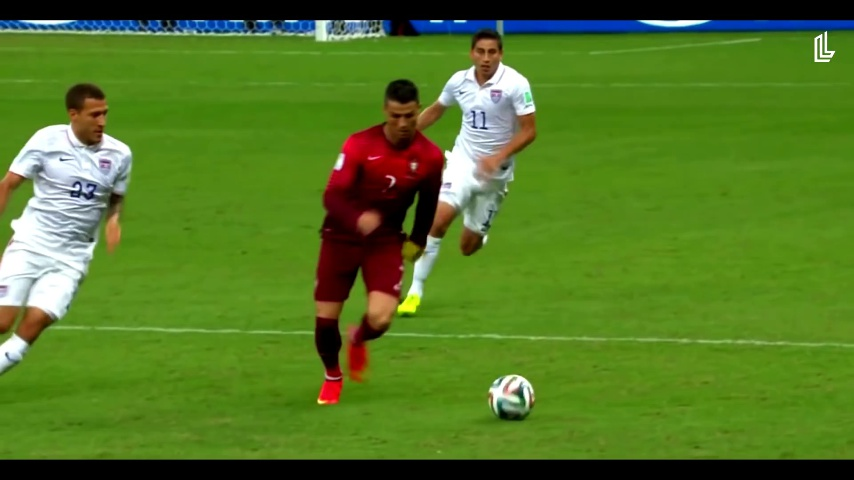

In [17]:
image

### 1 - Captions

In [52]:
task_prompt = '<CAPTION>'
florence_mamba(task_prompt)

'frame_details.txt'

In [53]:
task_prompt = '<DETAILED_CAPTION>'
florence_mamba(task_prompt)

'frame_details.txt'

In [21]:
task_prompt = '<MORE_DETAILED_CAPTION>'
florence_mamba(task_prompt)

{'<MORE_DETAILED_CAPTION>': 'The image shows a soccer match in progress. Two players from the opposing team, wearing white jerseys, are running towards the ball. The player in the red jersey is in possession of the ball and is attempting to dribble past the other player, who is wearing a white jersey with the number 11 on it. The ball is visible in the bottom right corner of the image. The background shows the field and the stands of the stadium. The image appears to have been taken from a high angle, looking down on the action.'}

### Read a Folder of Images

In [ ]:
from PIL import Image
import os
import matplotlib.pyplot as plt

def display_images_from_folder(folder_path, display_range=(0, 5)):
    image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

    image_files.sort()
    start_idx, end_idx = display_range
    selected_images = image_files[start_idx:end_idx]

    # Display the selected images
    for idx, image_path in enumerate(selected_images):
        image = Image.open(image_path)
        plt.figure()
        plt.imshow(image)
        plt.axis('off')  
        plt.title(f"Image {idx + start_idx}: {os.path.basename(image_path)}")
        plt.show()

folder_path = "frames/frames_from_121364_0"  
display_images_from_folder(folder_path, display_range=(0, 10)) 

### Generate Complete Folder Captions

In [ ]:
import os
from PIL import Image

def generate_captions_for_images(folder_path, task_prompt):
    image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

    image_files.sort()
    for idx, image_path in enumerate(image_files):
        image = Image.open(image_path)
        caption = florence_mamba(task_prompt, None, image)
        print(f"Caption for Image {idx + 1} ({os.path.basename(image_path)}):")
        print(caption)
        print("-" * 50) 

folder_path = "frames/frames_from_121364_0"
task_prompt = '<CAPTION>'
generate_captions_for_images(folder_path, task_prompt)

### Video Captions
> 1 - Read a single video   OR   
> 2 - Read folder containing videos   
> 3 - Save captions of a single video OR a folder of videos. 

In [ ]:
import os
import cv2
from PIL import Image

def generate_captions_for_folder_of_videos(folder_path, task_prompt, output_folder="video_captions"):
    os.makedirs(output_folder, exist_ok=True)
    video_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) 
                   if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]

    for video_path in video_files:
        print(f"Processing video: {os.path.basename(video_path)}")
        output_file = os.path.join(output_folder, f"{os.path.splitext(os.path.basename(video_path))[0]}_captions.txt")
        generate_captions_for_video(video_path, task_prompt, output_file)

def generate_captions_for_video(video_path, task_prompt, output_file):
    video = cv2.VideoCapture(video_path)
    frame_count = 0

    with open(output_file, 'w') as file:
        while video.isOpened():
            ret, frame = video.read()
            if not ret:
                break 

            frame_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            caption = florence_mamba(task_prompt, image=frame_image) 
            file.write(f"{frame_count}:\n{caption}\n\n")
            print(f"Caption for Frame {frame_count} saved.")
            frame_count += 1

    video.release()
    print(f"Finished processing video: {video_path}. Captions saved to {output_file}")

folder_path = "clips" 
task_prompt = '<MORE_DETAILED_CAPTION>'
generate_captions_for_folder_of_videos(folder_path, task_prompt)

### Behavior Analysis
> 1 - In a specific frame of the specific video    OR   
> 2 - From the complete video

In [ ]:
def analyze_captions_from_file(caption_file):
    with open(caption_file, 'r') as file:
        captions = file.readlines()
        for line in captions:
            if "Frame" in line:
                print(line.strip()) 
            else:
                print(f"Caption Analysis: {line.strip()}")

caption_file = "video_captions/121364_0_captions.txt"
analyze_captions_from_file(caption_file)

### Individual Player Analysis and Tactical Evaluation

In [ ]:
import cv2
from PIL import Image
import torch
from torchvision import transforms

def analyze_soccer_video(video_path, task_prompt, specific_frames=None):
    """
    Analyze soccer video to assess player performance, tactical analysis, or decision-making.
    
    Parameters:
        video_path (str): Path to the soccer video.
        task_prompt (str): Analysis prompt (e.g., "player performance", "tactical analysis").
        specific_frames (list): List of frame indices to analyze. If None, all frames are analyzed.
    """

    video = cv2.VideoCapture(video_path)
    frame_count = 0
    object_analysis_results = []

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224))  
    ])

    while video.isOpened():
        ret, frame = video.read()
        if not ret:
            break

        if specific_frames is None or frame_count in specific_frames:
            frame_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            input_tensor = transform(frame_image).unsqueeze(0).to('cuda', torch.float16)  
            result = florence_mamba(task_prompt, image=frame_image) 
            object_analysis_results.append({
                "frame": frame_count,
                "analysis": result
            })
            print(f"Analysis for Frame {frame_count}:\n{result}\n{'-'*50}")

        frame_count += 1

    video.release()
    return object_analysis_results

video_path = "clips/121364_0.mp4"
task_prompt = "<ANALYZE_PLAYER_PERFORMANCE>"  # Replace with specific analysis prompt as needed
specific_frames = [100, 200, 300]             # List of specific frames to analyze (optional)
results = analyze_soccer_video(video_path, task_prompt, specific_frames)

for res in results:
    print(f"Frame {res['frame']}: {res['analysis']}")

### Generate < DETAILED CAPTIONS > of a Specific Video Frames

In [ ]:
import os
from PIL import Image

def generate_captions_for_images(folder_path, task_prompt):
    image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

    image_files.sort()
    for idx, image_path in enumerate(image_files):
        image = Image.open(image_path)
        caption = florence_mamba(task_prompt, None, image)
        print(f"Caption for Image {idx + 1} ({os.path.basename(image_path)}):")
        print(caption)
        print("-" * 50) 

folder_path = "frames/frames_from_121364_0"
task_prompt = '<DETAILED_CAPTION>'
generate_captions_for_images(folder_path, task_prompt)

### Generate < MORE DETAILED CAPTIONS > of a Specific Video Frames

In [ ]:
import os
from PIL import Image

def generate_captions_for_images(folder_path, task_prompt):
    image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

    image_files.sort()
    for idx, image_path in enumerate(image_files):
        image = Image.open(image_path)
        caption = florence_mamba(task_prompt, None, image)
        print(f"Caption for Image {idx + 1} ({os.path.basename(image_path)}):")
        print(caption)
        print("-" * 50) 

folder_path = "frames/frames_from_121364_0"
task_prompt = '<MORE_DETAILED_CAPTION>'
generate_captions_for_images(folder_path, task_prompt)


### 2 - Object Detection

OD results format: 
{'\<OD>':
    {
    'bboxes': [[x1, y1, x2, y2], ...], 
    'labels': ['label1', 'label2', ...]
    } 
}

In [22]:
task_prompt = '<OD>'
results = m3f_florence(task_prompt)
print(results)

{'<OD>': {'bboxes': [[486.3529968261719, 374.1600036621094, 536.7389526367188, 420.7200012207031], [309.5749816894531, 78.47999572753906, 447.9229736328125, 405.3599853515625], [395.8289794921875, 29.51999855041504, 539.3009643554688, 317.03997802734375], [0.4269999861717224, 82.79999542236328, 134.50498962402344, 375.1199951171875]], 'labels': ['football', 'person', 'person', 'person']}}


In [27]:
import matplotlib.pyplot as plt  
import matplotlib.patches as patches  

def plot_bbox(image, data):
    fig, ax = plt.subplots()  
    ax.imshow(image)  
    for bbox, label in zip(data['bboxes'], data['labels']):  
        x1, y1, x2, y2 = bbox  
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='y', facecolor='none')  
        ax.add_patch(rect)  
        plt.text(x1, y1, label, color='white', fontsize=10, bbox=dict(facecolor='green', alpha=0.5))  
    ax.axis('off')  
    plt.show()  

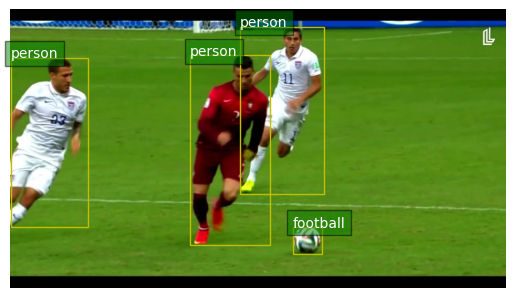

In [28]:
plot_bbox(image, results['<OD>'])

### 3 - Dense Region Caption

Output format: 
{'\<DENSE_REGION_CAPTION>': {'bboxes': [[x1, y1, x2, y2], ...], 'labels': ['label1', 'label2', ...]}}

In [29]:
task_prompt = '<DENSE_REGION_CAPTION>'
results = m3f_florence(task_prompt)
print(results)

{'<DENSE_REGION_CAPTION>': {'bboxes': [[309.5749816894531, 78.47999572753906, 448.7769775390625, 405.3599853515625], [396.6829833984375, 29.51999855041504, 540.1549682617188, 316.55999755859375], [0.4269999861717224, 82.31999969482422, 135.35899353027344, 375.1199951171875], [485.4989929199219, 374.1600036621094, 537.5929565429688, 420.7200012207031]], 'labels': ['Cristiano Ronaldo Portugal national football team', 'Alex Oxlade-Chamberlain USMNT soccer', 'Alex Morgan England national team goal celebration', 'football']}}


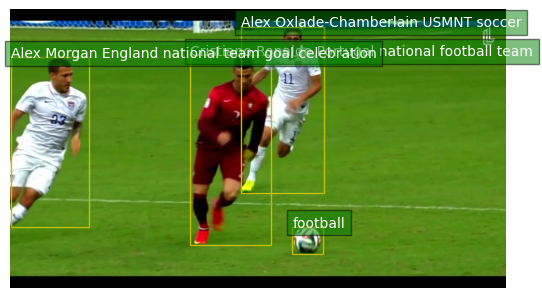

In [30]:
plot_bbox(image, results['<DENSE_REGION_CAPTION>'])

### 1 - Phrase Grounding
Phrase grounding results format: 
{'\<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[x1, y1, x2, y2], ...], 'labels': ['', '', ...]}}

In [33]:
task_prompt = '<CAPTION_TO_PHRASE_GROUNDING>'
results = m3f_florence(task_prompt, text_input="The image shows a soccer match in progress. Two players from the opposing team, wearing white jerseys, are running towards the ball. The player in the red jersey is in possession of the ball and is attempting to dribble past the other player, who is wearing a white jersey with the number 11 on it. The ball is visible in the bottom right corner of the image.")
print(results)

{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[308.7209777832031, 27.119998931884766, 541.0089721679688, 408.7200012207031], [310.4289855957031, 77.04000091552734, 447.0690002441406, 408.239990234375], [1.2809998989105225, 80.4000015258789, 136.21299743652344, 378.0], [395.8289794921875, 28.079999923706055, 540.1549682617188, 319.44000244140625], [308.7209777832031, 27.119998931884766, 540.1549682617188, 408.7200012207031], [7.258999824523926, 122.63999938964844, 135.35899353027344, 266.1600036621094], [435.96697998046875, 62.63999938964844, 538.4469604492188, 162.95999145507812], [485.4989929199219, 371.7599792480469, 537.5929565429688, 422.6399841308594], [310.4289855957031, 77.04000091552734, 447.9229736328125, 408.239990234375], [319.822998046875, 122.15999603271484, 447.0690002441406, 243.1199951171875], [1.2809998989105225, 80.4000015258789, 137.06700134277344, 378.0], [395.8289794921875, 27.599998474121094, 540.1549682617188, 319.44000244140625], [7.258999824523926, 122.63999938

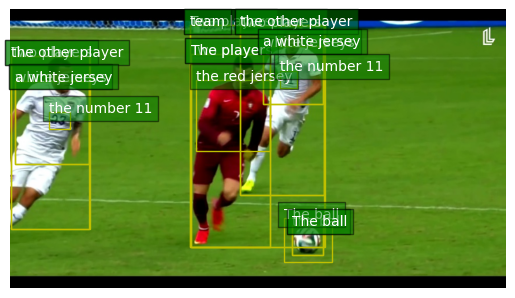

In [34]:
plot_bbox(image, results['<CAPTION_TO_PHRASE_GROUNDING>'])